In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
# import os
# os.chdir("/content")
# print(os.getcwd())

In [4]:
import os
import subprocess
import shutil

DRIVE_ROOT = "/content/drive/MyDrive/vlm-finetuning-project1"
REPO_DIR = "vlm-safety-reasoning"
ENV_PATH = f"{DRIVE_ROOT}/secrets/.env"

def load_secrets(env_path: str) -> dict:
    if not os.path.exists(env_path):
        raise FileNotFoundError(f"Secrets file not found at: {env_path}")
    secrets = {}
    with open(env_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#") or "=" not in line:
                continue
            key, value = line.split("=", 1)
            secrets[key] = value.strip(" \"'\r")
            os.environ[key] = secrets[key]
    return secrets

print(">>> Loading secrets...")
secrets = load_secrets(ENV_PATH)
required_keys = ["GIT_EMAIL", "GIT_NAME", "GITHUB_USERNAME", "GITHUB_TOKEN", "HF_TOKEN"]
missing = [k for k in required_keys if k not in secrets]
if missing:
    raise KeyError(f"Missing required secrets: {missing}")
print(">>> Secrets loaded successfully.")

print(">>> Configuring Git identity...")
subprocess.run(["git", "config", "--global", "user.email", secrets["GIT_EMAIL"]], check=True)
subprocess.run(["git", "config", "--global", "user.name", secrets["GIT_NAME"]], check=True)

AUTH_REPO_URL = (
    f"https://{secrets['GITHUB_USERNAME']}:{secrets['GITHUB_TOKEN']}"
    f"@github.com/epmresearch/vlm-safety-reasoning.git"
)

if os.path.exists(REPO_DIR):
    print(">>> Repo already present, pulling latest...")
    os.chdir(REPO_DIR)
    subprocess.run(["git", "remote", "set-url", "origin", AUTH_REPO_URL], check=True)
    subprocess.run(["git", "pull", "origin", "main"], check=True)
else:
    print(">>> Cloning repo...")
    subprocess.run(["git", "clone", AUTH_REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)

print(f">>> Working directory: {os.getcwd()}")
print(">>> Copying .env into local workspace...")
shutil.copy(ENV_PATH, ".env")

print(">>> Installing requirements...")
subprocess.run(["pip", "install", "-q", "-r", "requirements.txt"], check=True)
print(">>> Setup complete.")

>>> Loading secrets...
>>> Secrets loaded successfully.
>>> Configuring Git identity...
>>> Cloning repo...
>>> Working directory: /content/vlm-safety-reasoning
>>> Copying .env into local workspace...
>>> Installing requirements...
>>> Setup complete.


In [5]:
from huggingface_hub import login
login(token=os.environ["HF_TOKEN"])

import json
from datasets import DatasetDict, load_from_disk

from core.config import load_base_config
from core.io import get_drive_path, ensure_dir
from core.logging import get_logger
from core.constants import VALIDATION_SPLIT_SIZE, VALIDATION_SPLIT_SEED
from data.loader import load_cleaned_construction_dataset, create_stratified_val_split
from data.preprocessor import build_unified_sft_dataset
from evaluation.output_parser import parse_model_output, validate_unified_output

logger = get_logger("data_format_notebook")

base_cfg = load_base_config()
print("drive_root:", base_cfg["drive_root"])

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


drive_root: /content/drive/MyDrive/vlm-finetuning-project1


In [8]:
raw_dataset = load_cleaned_construction_dataset()
print(raw_dataset)

2026-07-15 11:41:35 | INFO     | data.loader:load_cleaned_construction_dataset:126 - Loading cleaned dataset from disk: /content/drive/MyDrive/vlm-finetuning-project1/datasets/raw_cleaned
2026-07-15 11:41:36 | INFO     | data.loader:load_cleaned_construction_dataset:130 - Train split size: 7009
2026-07-15 11:41:36 | INFO     | data.loader:load_cleaned_construction_dataset:132 - Test split size: 3004
DatasetDict({
    train: Dataset({
        features: ['image', 'image_id', 'image_caption', 'illumination', 'camera_distance', 'view', 'quality_of_info', 'rule_1_violation', 'rule_2_violation', 'rule_3_violation', 'rule_4_violation', 'excavator', 'rebar', 'worker_with_white_hard_hat'],
        num_rows: 7009
    })
    test: Dataset({
        features: ['image', 'image_id', 'image_caption', 'illumination', 'camera_distance', 'view', 'quality_of_info', 'rule_1_violation', 'rule_2_violation', 'rule_3_violation', 'rule_4_violation', 'excavator', 'rebar', 'worker_with_white_hard_hat'],
        

In [10]:
train_split, val_split = create_stratified_val_split(
    raw_dataset["train"],
    val_size=VALIDATION_SPLIT_SIZE,
    seed=VALIDATION_SPLIT_SEED,
)
test_split = raw_dataset["test"]

print(f"train={len(train_split)}  val={len(val_split)}  test={len(test_split)}")

splits = DatasetDict({
    "train": train_split,
    "val": val_split,
    "test": test_split,
})

2026-07-15 11:41:38 | INFO     | data.loader:create_stratified_val_split:50 - Computing strata for balanced train/val split...


Adding strata:   0%|          | 0/7009 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/7009 [00:00<?, ? examples/s]

2026-07-15 11:42:58 | INFO     | data.loader:create_stratified_val_split:85 - Stratified split complete: Train=6308, Val=701
train=6308  val=701  test=3004


In [11]:
SPLITS_PATH = get_drive_path("datasets", "processed")
ensure_dir(SPLITS_PATH)

print(f"Saving splits to: {SPLITS_PATH}")
splits.save_to_disk(str(SPLITS_PATH))
print("Saved.")

Saving splits to: /content/drive/MyDrive/vlm-finetuning-project1/datasets/processed


Saving the dataset (0/6 shards):   0%|          | 0/6308 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/701 [00:00<?, ? examples/s]

Saving the dataset (0/3 shards):   0%|          | 0/3004 [00:00<?, ? examples/s]

Saved.


In [6]:
SPLITS_PATH = get_drive_path("datasets", "processed")
splits_reloaded = load_from_disk(str(SPLITS_PATH))
print(splits_reloaded)
print("\nColumns:", splits_reloaded["train"].column_names)

DatasetDict({
    train: Dataset({
        features: ['image', 'image_id', 'image_caption', 'illumination', 'camera_distance', 'view', 'quality_of_info', 'rule_1_violation', 'rule_2_violation', 'rule_3_violation', 'rule_4_violation', 'excavator', 'rebar', 'worker_with_white_hard_hat'],
        num_rows: 6308
    })
    val: Dataset({
        features: ['image', 'image_id', 'image_caption', 'illumination', 'camera_distance', 'view', 'quality_of_info', 'rule_1_violation', 'rule_2_violation', 'rule_3_violation', 'rule_4_violation', 'excavator', 'rebar', 'worker_with_white_hard_hat'],
        num_rows: 701
    })
    test: Dataset({
        features: ['image', 'image_id', 'image_caption', 'illumination', 'camera_distance', 'view', 'quality_of_info', 'rule_1_violation', 'rule_2_violation', 'rule_3_violation', 'rule_4_violation', 'excavator', 'rebar', 'worker_with_white_hard_hat'],
        num_rows: 3004
    })
})

Columns: ['image', 'image_id', 'image_caption', 'illumination', 'camera_dista

In [7]:
print("Building unified conversation format for train (sanity check only)...")
train_conversations = build_unified_sft_dataset(splits_reloaded["train"])

print("Building unified conversation format for val (sanity check only)...")
val_conversations = build_unified_sft_dataset(splits_reloaded["val"])

print(f"train_conversations={len(train_conversations)}  val_conversations={len(val_conversations)}")

Building unified conversation format for train (sanity check only)...
2026-07-15 11:56:31 | INFO     | data.preprocessor:build_unified_sft_dataset:121 - Built unified SFT dataset: 6308 samples (0 skipped)
Building unified conversation format for val (sanity check only)...
2026-07-15 11:56:41 | INFO     | data.preprocessor:build_unified_sft_dataset:121 - Built unified SFT dataset: 701 samples (0 skipped)
train_conversations=6308  val_conversations=701


In [8]:
train_conversations[0]

{'messages': [{'role': 'system',
   'content': [{'type': 'text',
     'text': 'You are an expert AI construction safety inspector. Analyze the construction site image and output a single JSON code block containing your full inspection. You must strictly adhere to the requested JSON schema. Absolutely no conversational text, preambles, or explanations outside the ```json ... ``` fences.'}]},
  {'role': 'user',
   'content': [{'type': 'image',
     'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=906x765>},
    {'type': 'text',
     'text': 'Perform a full site inspection of this construction image. Your response must include ALL of the following in a single JSON object:\n\n1. CAPTION — a detailed description covering both foreground and background elements (workers, equipment, PPE, material stockpiles, site conditions).\n\n2. DETECTED OBJECTS — bounding boxes for every instance of:\n   - excavator\n   - rebar\n   - worker_with_white_hard_hat\n   If an object class is abse

In [9]:
sample_conv = train_conversations[0]
printable = json.loads(json.dumps(sample_conv, default=lambda o: "<PIL Image>"))
print("\n=== Sample conversation structure ===")
print(json.dumps(printable, indent=2))


=== Sample conversation structure ===
{
  "messages": [
    {
      "role": "system",
      "content": [
        {
          "type": "text",
          "text": "You are an expert AI construction safety inspector. Analyze the construction site image and output a single JSON code block containing your full inspection. You must strictly adhere to the requested JSON schema. Absolutely no conversational text, preambles, or explanations outside the ```json ... ``` fences."
        }
      ]
    },
    {
      "role": "user",
      "content": [
        {
          "type": "image",
          "image": "<PIL Image>"
        },
        {
          "type": "text",
          "text": "Perform a full site inspection of this construction image. Your response must include ALL of the following in a single JSON object:\n\n1. CAPTION \u2014 a detailed description covering both foreground and background elements (workers, equipment, PPE, material stockpiles, site conditions).\n\n2. DETECTED OBJECTS \u2014 

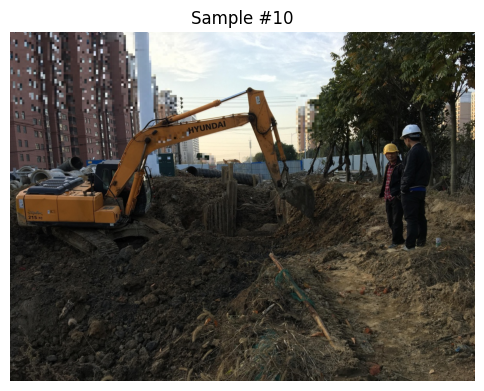

=== Target JSON string (as the model will be trained on) ===
```json
{"caption":"The image shows an excavator in the middle of digging, with its bucket raised and full of dirt. Two workers wearing hard hats are standing to the right, appearing to be in a discussion. Behind them, there are trees and a fence separating the construction area from high-rise buildings.","rule_1_violation":null,"rule_2_violation":null,"rule_3_violation":null,"rule_4_violation":null,"excavator":[[10,150,660,650]],"rebar":[],"worker_with_white_hard_hat":[[830,260,910,640]]}
```

Parses as JSON: True
Schema valid: True


In [11]:
import matplotlib.pyplot as plt

idx = 10
conv = train_conversations[idx]
pil_image = conv["messages"][1]["content"][0]["image"]
target_str = conv["messages"][2]["content"][0]["text"]

plt.figure(figsize=(6, 6))
plt.imshow(pil_image)
plt.axis("off")
plt.title(f"Sample #{idx}")
plt.show()

print("=== Target JSON string (as the model will be trained on) ===")
print(target_str)

parsed = parse_model_output(target_str)
print("\nParses as JSON:", parsed is not None)
if parsed is not None:
    print("Schema valid:", validate_unified_output(parsed) is not None)

In [13]:
import pandas as pd
from data.loader import _compute_stratum

In [14]:
STRATUM_LABELS = {
    0: "Rule 4 (Blind Spot)",
    1: "Rule 2 (Harness)",
    2: "Rule 3 (Edge Protection)",
    3: "Rule 1 (PPE)",
    4: "White Hard Hat (no violation)",
    5: "Rebar (no violation)",
    6: "Excavator (no violation)",
    7: "None of the above",
}

def compute_stratum_distribution(dataset, split_name):
    counts = {i: 0 for i in range(8)}
    for sample in dataset:
        s = _compute_stratum(sample)
        counts[s] += 1

    total = len(dataset)
    rows = []
    for stratum_id, label in STRATUM_LABELS.items():
        count = counts[stratum_id]
        pct = (count / total * 100) if total > 0 else 0.0
        rows.append({
            "split": split_name,
            "stratum_id": stratum_id,
            "label": label,
            "count": count,
            "pct": round(pct, 2),
        })
    return rows


all_rows = []
for split_name, ds in [("train", splits_reloaded["train"]),
                       ("val", splits_reloaded["val"]),
                       ("test", splits_reloaded["test"])]:
    all_rows.extend(compute_stratum_distribution(ds, split_name))

df_strata = pd.DataFrame(all_rows)

print(f"Total samples — train={len(splits_reloaded['train'])}  "
      f"val={len(splits_reloaded['val'])}  test={len(splits_reloaded['test'])}\n")

pivot_pct = df_strata.pivot(index="label", columns="split", values="pct")
pivot_pct = pivot_pct[["train", "val", "test"]]
print("=== Stratum Percentage Distribution (%) ===")
display(pivot_pct)

pivot_count = df_strata.pivot(index="label", columns="split", values="count")
pivot_count = pivot_count[["train", "val", "test"]]
print("\n=== Stratum Raw Counts ===")
display(pivot_count)

Total samples — train=6308  val=701  test=3004

=== Stratum Percentage Distribution (%) ===


split,train,val,test
label,,,
Excavator (no violation),26.14,26.11,26.86
None of the above,43.31,43.37,41.94
Rebar (no violation),10.21,10.27,9.15
Rule 1 (PPE),9.32,9.27,10.09
Rule 2 (Harness),0.84,0.86,0.83
Rule 3 (Edge Protection),1.54,1.57,1.96
Rule 4 (Blind Spot),0.67,0.57,0.80
White Hard Hat (no violation),7.97,7.99,8.36



=== Stratum Raw Counts ===


split,train,val,test
label,,,
Excavator (no violation),1649,183,807
None of the above,2732,304,1260
Rebar (no violation),644,72,275
Rule 1 (PPE),588,65,303
Rule 2 (Harness),53,6,25
Rule 3 (Edge Protection),97,11,59
Rule 4 (Blind Spot),42,4,24
White Hard Hat (no violation),503,56,251


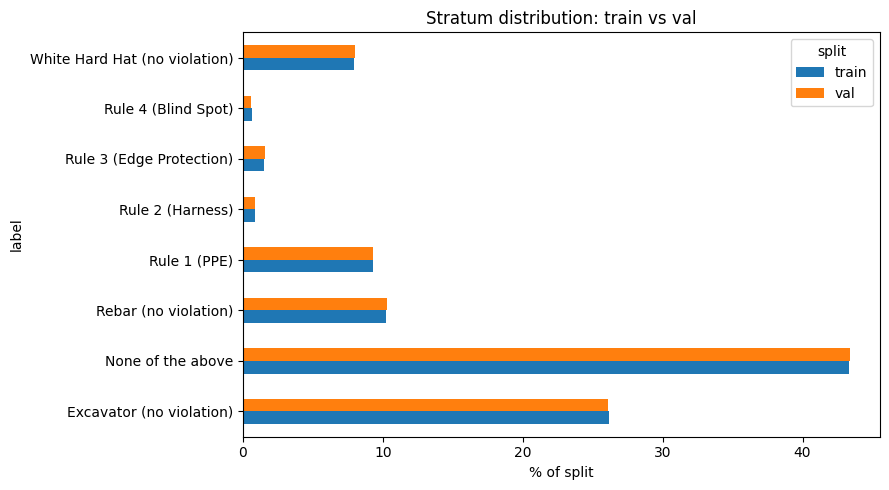

In [15]:
import matplotlib.pyplot as plt

pivot_pct[["train", "val"]].plot(kind="barh", figsize=(9, 5))
plt.xlabel("% of split")
plt.title("Stratum distribution: train vs val")
plt.tight_layout()
plt.show()

In [16]:
from core.io import get_drive_path, ensure_dir

STATS_DIR = get_drive_path("datasets", "stats")
ensure_dir(STATS_DIR)

long_form_path = STATS_DIR / "stratum_distribution_long.csv"
df_strata.to_csv(long_form_path, index=False)
print(f"Saved long-form stats to: {long_form_path}")

pct_path = STATS_DIR / "stratum_distribution_pct.csv"
pivot_pct.to_csv(pct_path)
print(f"Saved percentage pivot to: {pct_path}")

counts_path = STATS_DIR / "stratum_distribution_counts.csv"
pivot_count.to_csv(counts_path)
print(f"Saved counts pivot to: {counts_path}")

Saved long-form stats to: /content/drive/MyDrive/vlm-finetuning-project1/datasets/stats/stratum_distribution_long.csv
Saved percentage pivot to: /content/drive/MyDrive/vlm-finetuning-project1/datasets/stats/stratum_distribution_pct.csv
Saved counts pivot to: /content/drive/MyDrive/vlm-finetuning-project1/datasets/stats/stratum_distribution_counts.csv
